In [ ]:
!pip install transformers-interpret

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.9/45.9 kB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 26.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 26.0 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is 

#Import

In [ ]:
# ============================================================
# 0) Setup
# ============================================================
import sys, subprocess, importlib, re, math, warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_columns", 200)

# If transformers is not installed, install it in Colab.
try:
    from transformers import AutoTokenizer
except Exception:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "transformers"])
    from transformers import AutoTokenizer

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    MarianMTModel, MarianTokenizer, get_linear_schedule_with_warmup
)
from torch.optim import AdamW
from transformers_interpret import SequenceClassificationExplainer
from sklearn.metrics import classification_report, f1_score, accuracy_score
import time
from datetime import datetime
import os
import gc
import gdown

url = "https://drive.google.com/drive/folders/1V3Jy2FbjO0cAlYv5cWZW16E0GtMhF5QB?usp=sharing"
gdown.download_folder(url)

CKPT_DIR = '/content/DL/'
os.makedirs(CKPT_DIR, exist_ok=True)
LOAD_CKPT = True

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Retrieving folder contents


Retrieving folder 1KdpFH1f_Wq8JTY-YvXdSQ6By5csSsDRZ best_model_bert_frz_aggr_std
Processing file 1cfjKTv2tJT1BmkwVKjsaSMmhbWU7GG9V config.json
Processing file 1BhuAG7QbM33kG5iyAFAocHyfeZxIew42 model.safetensors
Processing file 1RN1JrZIP7eH5XR9AafKUfLNZZ9bvmg4f tokenizer_config.json
Processing file 1NwHqoxBr-WKEf59wtgShD6w7z7BA1GDx tokenizer.json
Retrieving folder 1CRTrk9tzGlCtw5i71FfblMY18VUHKICW best_model_bert_frz_min_aug
Processing file 1URH5dSg8utXpJvSnIguQg8-OK1O09Js6 config.json
Processing file 1RCg8yZZ5noF-_Ibbuzv9SGSc4D1AWV1h model.safetensors
Processing file 1j9qm4atcq9s4aSL-5ixJ1Sg8AWAidqIC tokenizer_config.json
Processing file 1looVb54Jc68HZXmywpKdwzfeWQhcqp3A tokenizer.json
Retrieving folder 1Q1Q4qEoKY2Wjy8k_yz_SgPJigHxr4ePc best_model_bert_frz_min_std
Processing file 194EUTT_5-pAhE_jEaqxGLVDfcjnLiaxt config.json
Processing file 1YpfE1tJl4r6X5ACJm3NU8YsqK0HEENCg model.safetensors
Processing file 1oMY0Cz5G2TqN3SHAcKzybSV_GXs5I5vd tokenizer_config.json
Processing file 1OcZOyn

Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1cfjKTv2tJT1BmkwVKjsaSMmhbWU7GG9V
To: /content/DL/best_model_bert_frz_aggr_std/config.json
100%|██████████| 1.03k/1.03k [00:00<00:00, 4.21MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1BhuAG7QbM33kG5iyAFAocHyfeZxIew42
From (redirected): https://drive.google.com/uc?id=1BhuAG7QbM33kG5iyAFAocHyfeZxIew42&confirm=t&uuid=d64dd04e-b55f-4075-8fdd-f01b7b4d5073
To: /content/DL/best_model_bert_frz_aggr_std/model.safetensors
100%|██████████| 438M/438M [00:11<00:00, 37.8MB/s]
Downloading...
From: https://drive.google.com/uc?id=1RN1JrZIP7eH5XR9AafKUfLNZZ9bvmg4f
To: /content/DL/best_model_bert_frz_aggr_std/tokenizer_config.json
100%|██████████| 322/322 [00:00<00:00, 1.29MB/s]
Downloading...
From: https://drive.google.com/uc?id=1NwHqoxBr-WKEf59wtgShD6w7z7BA1GDx
To: /content/DL/best_model_bert_frz_aggr_std/tokenizer.json
100%

Using device: cuda



Download completed


## 1. Load Data

,type,sub_type,text,listPrice,sqft,stories,beds,baths,baths_full,baths_full_calc,garage,year_built
0,single_family,NaN,"Showings subject to accepted offer. Investor opportunity in Cathedral Park on a nearly 10,000 sq ft CM3-zoned lot. P...",179950.0,698.0,1.0,2.0,1.0,1.0,1.0,NaN,1897.0
1,single_family,NaN,"*DO NOT DRIVE BY WITHOUT AN APPOINTMENT* Distressed property due to land movement, drainage and foundation damage. T...",399900.0,2736.0,2.0,4.0,2.0,2.0,2.0,2.0,1990.0
2,condos,condo,This exceptional property is priced to sell & is a must-see for fly fishing enthusiasts. One-quarter shared interest...,220000.0,1130.0,1.0,3.0,3.0,3.0,3.0,NaN,2011.0
3,single_family,NaN,Commercially zoned property currently utilized as a residence with flexible living space. The upper level functions ...,230000.0,1293.0,2.0,3.0,2.0,2.0,2.0,1.0,1956.0
4,condos,condo,Sophisticated and beautifully updated riverfront townhome in an exceptional location just steps from the Willamette ...,899000.0,3172.0,3.0,3.0,4.0,4.0,4.0,1.0,2006.0


## 2. Label & Text Cleaning

,Value
,
Before cleaning,10403
After cleaning,10384
Rows removed,19
Unique labels,8


,count
type,
single_family,6545
land,1868
condos,858
townhomes,496
multi_family,411
farm,192
townhome,8
unknown,6


## 3. Label Distribution

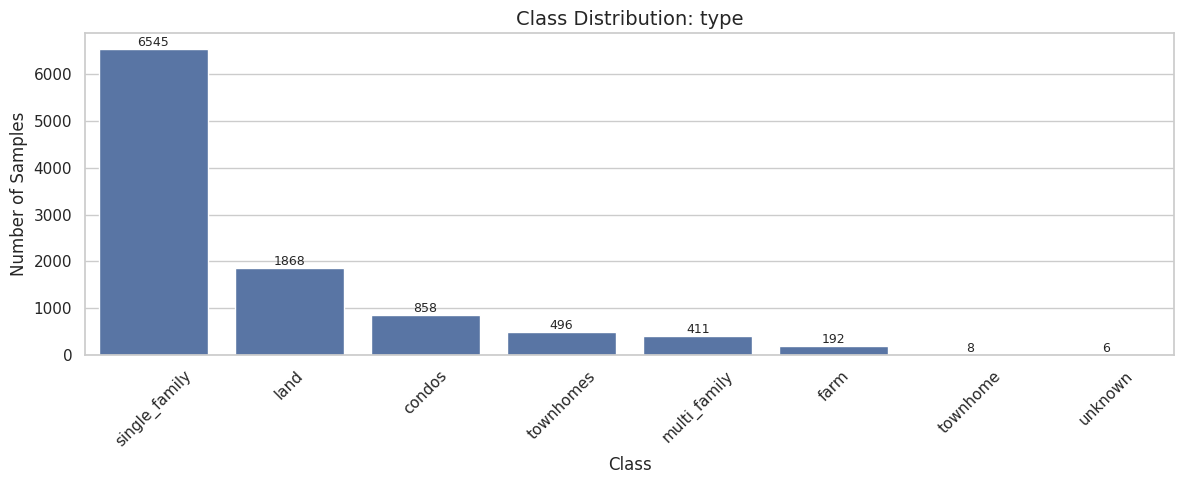

,class,count,class_weight
0,single_family,6545,0.1983
1,land,1868,0.6949
2,condos,858,1.5128
3,townhomes,496,2.6169
4,multi_family,411,3.1582
5,farm,192,6.7604
6,townhome,8,162.2500
7,unknown,6,216.3333


## 4. Missing Values by Class

,year_built,listPrice,sqft,stories,beds,baths,baths_full,baths_full_calc,garage
type,,,,,,,,,
condos,0.0,0.0,0.0,1.2,0.0,0.0,0.1,0.1,40.3
farm,74.5,0.0,69.8,72.4,67.7,65.1,67.7,67.7,82.8
land,100.0,0.0,100.0,100.0,100.0,89.8,100.0,100.0,98.8
multi_family,0.5,0.0,15.3,27.0,16.3,15.6,15.8,15.8,68.9
single_family,4.8,0.0,0.1,1.2,0.0,1.8,0.4,0.3,16.1
townhome,100.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0
townhomes,3.6,0.0,0.0,0.6,0.0,0.0,0.2,0.2,13.3
unknown,100.0,0.0,0.0,16.7,0.0,100.0,0.0,0.0,0.0


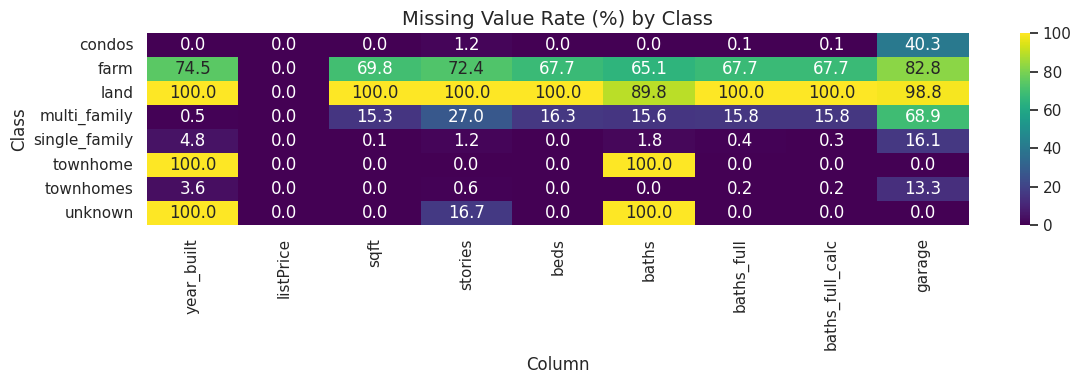

## 5. Text Length Analysis

,percentile,char_len,word_len
0,50%,809.00,131.0
1,75%,1084.00,174.0
2,90%,1551.00,246.0
3,95%,1828.85,288.0
4,99%,1996.17,325.0


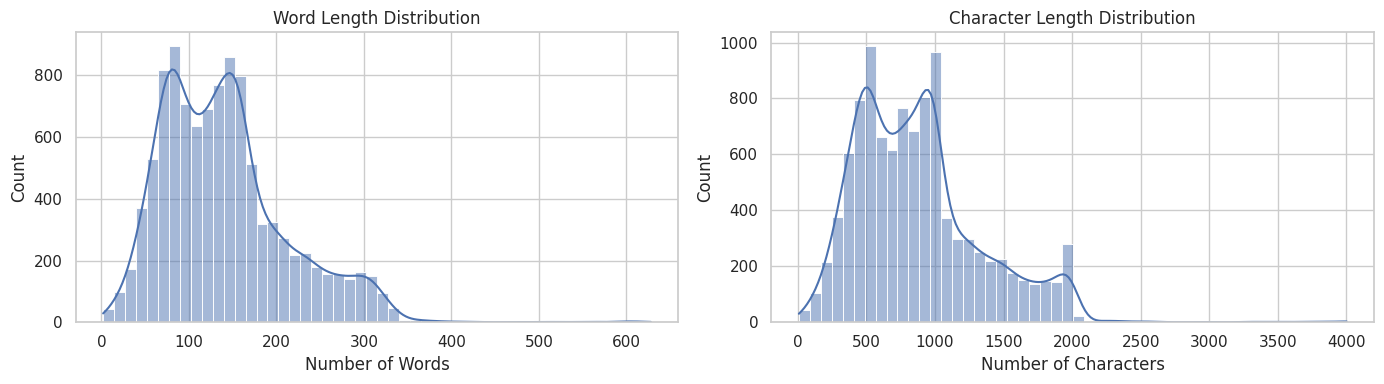

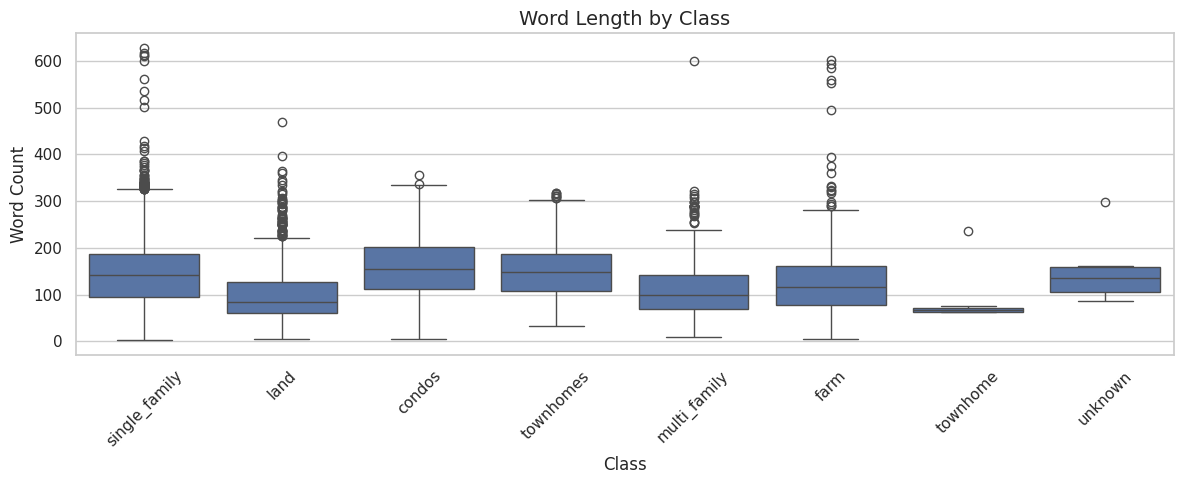

## 6. Train / Val / Test Split

,Rows
Split,
Train,8307
Val,1038
Test,1039


,train_%,val_%,test_%
type,,,
single_family,63.03,63.49,62.56
land,17.98,17.15,18.86
condos,8.26,8.29,8.28
townhomes,4.78,4.24,5.29
multi_family,3.96,4.62,3.27
farm,1.85,2.12,1.54
townhome,0.07,0.00,0.19
unknown,0.06,0.10,0.00


## 7. Preprocessing Comparison

,variant,num_docs,avg_words,median_words,p95_words,vocab_size,rare_tokens_once,total_tokens,avg_unique_tokens_per_doc
0,minimal,8307,140.35,131.0,287.0,18233,7267,1165849,102.93
1,aggressive,8307,93.17,86.0,190.0,17427,6943,774001,81.62


...

## 11. EDA Summary & Recommendations

,Value
Number of classes,8.00
Imbalance ratio (max/min),1090.83
Avg OOV rate — val/test (%),0.69
Train vocab size,18233.00
Recommended RNN embedding vocab size,2926.00
Recommended LSTM max_length (words),512.00


,Recommendation
0,✅ Use class weights in loss function.
1,ℹ️ Manageable vocabulary → a well-tuned BiLSTM can be a strong baseline.
2,ℹ️ Text lengths concentrated → a single fixed max_length is sufficient.


### Suggested Next Experiments

,Experiment
#,
1,"BiLSTM/GRU with embedding_dim 100–300, bidirectional=True, dropout 0.2–0.5"
2,"Transformer fine-tuning with EDA-derived max_length, batch_size 8–16"
3,Compare weighted cross-entropy vs unweighted cross-entropy


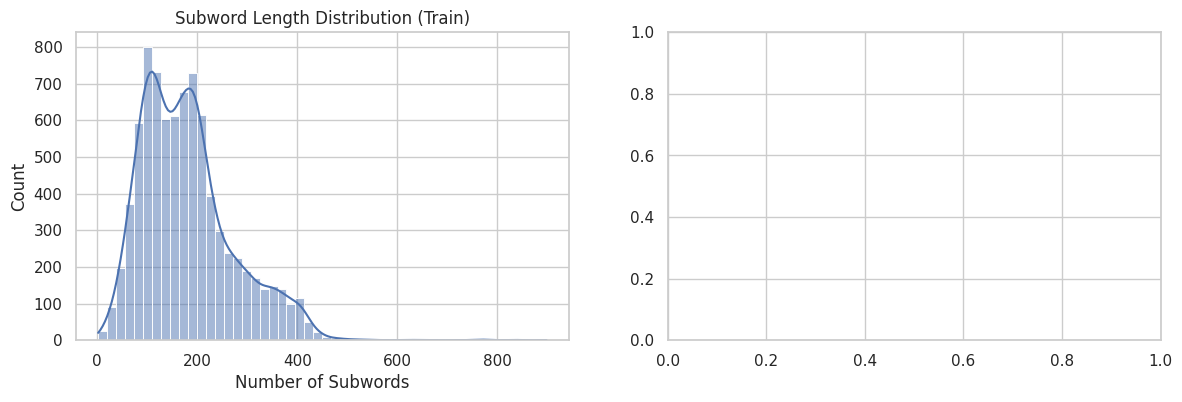

In [ ]:
# ============================================================
# 1) Load dataset
# ============================================================
display(Markdown("## 1. Load Data"))

file_path = '/content/DL/oregon_real_estate_2026_ultimate.csv'
df = pd.read_csv(file_path)
df.columns = [c.strip() for c in df.columns]

required_cols = {"type", "text"}
missing_required = required_cols - set(df.columns)
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

display(df.head())

# ============================================================
# 2) Clean target and text
# ============================================================
display(Markdown("## 2. Label & Text Cleaning"))

before_rows = len(df)
df = df.dropna(subset=["type", "text"]).copy()
df["type"] = df["type"].astype(str).str.strip().str.lower()
df["text"] = df["text"].astype(str).str.replace(r"\s+", " ", regex=True).str.strip()
df = df[df["text"].ne("")].copy()
after_rows = len(df)

cleaning_summary = pd.DataFrame({
    "": ["Before cleaning", "After cleaning", "Rows removed", "Unique labels"],
    "Value": [before_rows, after_rows, before_rows - after_rows, df["type"].nunique()]
})
display(cleaning_summary.set_index(""))

label_counts = df["type"].value_counts()
display(label_counts.to_frame("count"))

# ============================================================
# 3) Label distribution
# ============================================================
display(Markdown("## 3. Label Distribution"))

fig, ax = plt.subplots(figsize=(12, 5))
order = label_counts.index.tolist()
sns.barplot(x=label_counts.index, y=label_counts.values, ax=ax)
ax.set_title("Class Distribution: type", fontsize=14)
ax.set_xlabel("Class")
ax.set_ylabel("Number of Samples")
ax.tick_params(axis="x", rotation=45)
for i, v in enumerate(label_counts.values):
    ax.text(i, v, str(v), ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

imbalance_ratio = label_counts.max() / label_counts.min()
n_classes = df["type"].nunique()
total = len(df)
class_weights = {cls: total / (n_classes * cnt) for cls, cnt in label_counts.items()}
class_weights_df = pd.DataFrame({
    "class": list(class_weights.keys()),
    "count": [label_counts[c] for c in class_weights.keys()],
    "class_weight": [round(class_weights[c], 4) for c in class_weights.keys()]
}).sort_values("count", ascending=False).reset_index(drop=True)
display(class_weights_df)

# ============================================================
# 4) Missing-value analysis by label
# ============================================================
display(Markdown("## 4. Missing Values by Class"))

numeric_cols = [
    "year_built", "listPrice", "sqft", "stories", "beds", "baths",
    "baths_full", "baths_full_calc", "garage"
]
existing_numeric_cols = [c for c in numeric_cols if c in df.columns]

if existing_numeric_cols:
    missing_by_class = (
        df.groupby("type")[existing_numeric_cols]
          .apply(lambda g: g.isna().mean() * 100)
          .round(1)
    )
    display(missing_by_class)

    plt.figure(figsize=(12, max(4, 0.45 * len(missing_by_class))))
    sns.heatmap(missing_by_class, annot=True, fmt=".1f", cmap="viridis")
    plt.title("Missing Value Rate (%) by Class", fontsize=14)
    plt.xlabel("Column")
    plt.ylabel("Class")
    plt.tight_layout()
    plt.show()

# ============================================================
# 5) Text length analysis
# ============================================================
display(Markdown("## 5. Text Length Analysis"))

TOKEN_RE = re.compile(r"[A-Za-z0-9]+(?:'[A-Za-z0-9]+)?")
STOPWORDS = set(ENGLISH_STOP_WORDS)

def basic_tokens(text: str):
    return TOKEN_RE.findall(str(text).lower())

def aggressive_preprocess(text: str):
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    tokens = [t for t in text.split() if t not in STOPWORDS]
    return " ".join(tokens)

df["char_len"] = df["text"].str.len()
df["word_len"] = df["text"].apply(lambda x: len(basic_tokens(x)))

percentiles = [0.5, 0.75, 0.9, 0.95, 0.99]
text_len_summary = pd.DataFrame({
    "percentile": [f"{int(p*100)}%" for p in percentiles],
    "char_len": [df["char_len"].quantile(p) for p in percentiles],
    "word_len": [df["word_len"].quantile(p) for p in percentiles],
})
display(text_len_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df["word_len"], bins=50, ax=axes[0], kde=True)
axes[0].set_title("Word Length Distribution")
axes[0].set_xlabel("Number of Words")

sns.histplot(df["char_len"], bins=50, ax=axes[1], kde=True)
axes[1].set_title("Character Length Distribution")
axes[1].set_xlabel("Number of Characters")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=df, x="type", y="word_len", ax=ax, order=label_counts.index)
ax.set_title("Word Length by Class", fontsize=14)
ax.set_xlabel("Class")
ax.set_ylabel("Word Count")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

word_p50 = df["word_len"].quantile(0.50)
word_p95 = df["word_len"].quantile(0.95)
word_p99 = df["word_len"].quantile(0.99)

if word_p95 <= 64:
    recommended_lstm_max_len = 64
elif word_p95 <= 128:
    recommended_lstm_max_len = 128
elif word_p95 <= 256:
    recommended_lstm_max_len = 256
else:
    recommended_lstm_max_len = 512

spread_ratio = word_p95 / max(word_p50, 1)

# ============================================================
# 6) Train / val / test split
# ============================================================
display(Markdown("## 6. Train / Val / Test Split"))

model_df = df[["type", "text"]].copy()
min_class_count = model_df["type"].value_counts().min()
use_stratify = min_class_count >= 3
stratify_arg = model_df["type"] if use_stratify else None

train_df, temp_df = train_test_split(
    model_df, test_size=0.20, random_state=42, stratify=stratify_arg
)
stratify_temp = temp_df["type"] if (use_stratify and temp_df["type"].value_counts().min() >= 2) else None
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=42, stratify=stratify_temp
)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

split_sizes = pd.DataFrame({
    "Split": ["Train", "Val", "Test"],
    "Rows": [len(train_df), len(val_df), len(test_df)]
}).set_index("Split")
display(split_sizes)

def split_summary(df_part, name):
    return df_part["type"].value_counts(normalize=True).mul(100).round(2).rename(name)

split_dist = pd.concat(
    [split_summary(train_df, "train_%"), split_summary(val_df, "val_%"), split_summary(test_df, "test_%")],
    axis=1
).fillna(0)
display(split_dist)

# ============================================================
# 7) Compare preprocessing styles
# ============================================================
display(Markdown("## 7. Preprocessing Comparison"))

for part in [train_df, val_df, test_df]:
    part["text_min"]  = part["text"].str.lower().str.replace(r"\s+", " ", regex=True).str.strip()
    part["text_aggr"] = part["text"].apply(aggressive_preprocess)

def tokenize_series(series):
    return series.apply(basic_tokens)

def corpus_stats(text_series):
    token_lists = tokenize_series(text_series)
    lengths     = token_lists.apply(len)
    all_tokens  = [tok for tokens in token_lists for tok in tokens]
    vocab       = Counter(all_tokens)
    return {
        "num_docs":                    len(text_series),
        "avg_words":                   round(lengths.mean(), 2),
        "median_words":                lengths.median(),
        "p95_words":                   lengths.quantile(0.95),
        "vocab_size":                  len(vocab),
        "rare_tokens_once":            sum(1 for _, c in vocab.items() if c == 1),
        "total_tokens":                len(all_tokens),
        "avg_unique_tokens_per_doc":   round(token_lists.apply(lambda x: len(set(x))).mean(), 2),
    }

raw_stats  = corpus_stats(train_df["text_min"])
aggr_stats = corpus_stats(train_df["text_aggr"])

preprocess_compare = pd.DataFrame([
    {"variant": "minimal",    **raw_stats},
    {"variant": "aggressive", **aggr_stats},
])
display(preprocess_compare)

# ============================================================
# 8) Word-level vocabulary analysis (train only)
# ============================================================
display(Markdown("## 8. Vocabulary Analysis (Train)"))

train_tokens = [tok for text in train_df["text_min"] for tok in basic_tokens(text)]
val_tokens   = [tok for text in val_df["text_min"]   for tok in basic_tokens(text)]
test_tokens  = [tok for text in test_df["text_min"]  for tok in basic_tokens(text)]

train_counter = Counter(train_tokens)
train_vocab   = set(train_counter.keys())

def oov_rate(tokens, vocab):
    if len(tokens) == 0:
        return np.nan
    return sum(tok not in vocab for tok in tokens) / len(tokens)

oov_val  = oov_rate(val_tokens,  train_vocab)
oov_test = oov_rate(test_tokens, train_vocab)
rare_once  = sum(1 for _, c in train_counter.items() if c == 1)
rare_share = rare_once / max(len(train_counter), 1)

vocab_summary = pd.DataFrame({
    "Metric": [
        "Train unique vocab size",
        "Tokens appearing once",
        "Rare token share (%)",
        "OOV rate — val (%)",
        "OOV rate — test (%)",
    ],
    "Value": [
        len(train_vocab),
        rare_once,
        round(rare_share * 100, 2),
        round(oov_val  * 100, 2),
        round(oov_test * 100, 2),
    ]
}).set_index("Metric")
display(vocab_summary)

freqs        = np.array(sorted(train_counter.values(), reverse=True))
cum_coverage = np.cumsum(freqs) / freqs.sum()

def coverage_at_k(k):
    if len(freqs) == 0:
        return np.nan
    k = min(k, len(freqs))
    return cum_coverage[k - 1]

coverage_ks = [1000, 2000, 5000, 10000, 20000, 30000]
coverage_table = pd.DataFrame({
    "top_k_vocab":              coverage_ks,
    "token_coverage_train_%":   [round(100 * coverage_at_k(k), 2) for k in coverage_ks],
})
display(coverage_table)

recommended_vocab = None
for i, cov in enumerate(cum_coverage, start=1):
    if cov >= 0.95:
        recommended_vocab = i
        break
if recommended_vocab is None:
    recommended_vocab = len(train_counter)

# ============================================================
# 9) Top n-grams per class
# ============================================================
display(Markdown("## 9. Top N-grams per Class (Train)"))

def top_ngrams_for_class(dataframe, class_name, text_col="text_aggr", ngram_range=(1, 2), top_n=10, min_df=2):
    subset    = dataframe[dataframe["type"] == class_name]
    texts     = subset[text_col].tolist()
    if len(texts) == 0:
        return pd.DataFrame(columns=["class", "ngram", "count"])
    local_min_df = min(min_df, max(1, len(texts)))
    try:
        vec      = CountVectorizer(ngram_range=ngram_range, min_df=local_min_df)
        X        = vec.fit_transform(texts)
        counts   = np.asarray(X.sum(axis=0)).ravel()
        terms    = np.array(vec.get_feature_names_out())
        top_idx  = counts.argsort()[::-1][:top_n]
        return pd.DataFrame({"class": class_name, "ngram": terms[top_idx], "count": counts[top_idx]})
    except Exception:
        return pd.DataFrame(columns=["class", "ngram", "count"])

classes         = train_df["type"].value_counts().index.tolist()
top_ngram_tables = [
    top_ngrams_for_class(train_df, cls, text_col="text_aggr", ngram_range=(1, 2), top_n=10, min_df=2)
    for cls in classes
]
top_ngrams_df = pd.concat(top_ngram_tables, ignore_index=True)

for cls in classes:
    display(Markdown(f"### `{cls}`"))
    display(top_ngrams_df[top_ngrams_df["class"] == cls].reset_index(drop=True))

# ============================================================
# 10) Transformer tokenization stats
# ============================================================
display(Markdown("## 10. Transformer Tokenization Stats"))

try:
    tokenizer_name = "bert-base-uncased"
    tokenizer      = AutoTokenizer.from_pretrained(tokenizer_name, use_fast=True)

    def subword_lengths(texts):
        enc = tokenizer(list(texts), add_special_tokens=False, padding=False, truncation=False)
        return np.array([len(ids) for ids in enc["input_ids"]], dtype=int)

    train_sub_len = subword_lengths(train_df["text_min"])
    val_sub_len   = subword_lengths(val_df["text_min"])
    test_sub_len  = subword_lengths(test_df["text_min"])

    subword_stats = pd.DataFrame({
        "split":        ["train", "val", "test"],
        "avg_subwords": [train_sub_len.mean(), val_sub_len.mean(), test_sub_len.mean()],
        "p50_subwords": [np.quantile(s, 0.50) for s in [train_sub_len, val_sub_len, test_sub_len]],
        "p95_subwords": [np.quantile(s, 0.95) for s in [train_sub_len, val_sub_len, test_sub_len]],
        "p99_subwords": [np.quantile(s, 0.99) for s in [train_sub_len, val_sub_len, test_sub_len]],
        "max_subwords": [s.max() for s in [train_sub_len, val_sub_len, test_sub_len]],
    }).round(2)
    display(subword_stats)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    sns.histplot(train_sub_len, bins=50, ax=axes[0], kde=True)
    axes[0].set_title("Subword Length Distribution (Train)")
    axes[0].set_xlabel("Number of Subwords")

    sns.histplot(train_sub_len / np.maximum(train_df["word_len"].values, 1), bins=50, ax=axes[1], kde=True)
    axes[1].set_title("Subword-to-Word Ratio (Train)")
    axes[1].set_xlabel("Subwords / Words")
    plt.tight_layout()
    plt.show()

    subword_p50 = np.quantile(train_sub_len, 0.50)
    subword_p95 = np.quantile(train_sub_len, 0.95)
    subword_p99 = np.quantile(train_sub_len, 0.99)
    subword_ratio = subword_p95 / max(subword_p50, 1)

    if subword_p95 <= 64:
        recommended_transformer_max_len = 64
    elif subword_p95 <= 128:
        recommended_transformer_max_len = 128
    elif subword_p95 <= 256:
        recommended_transformer_max_len = 256
    else:
        recommended_transformer_max_len = 512

except Exception as e:
    recommended_transformer_max_len = None

# ============================================================
# 11) EDA-driven recommendation summary
# ============================================================
display(Markdown("## 11. EDA Summary & Recommendations"))

oov_avg      = np.nanmean([oov_val, oov_test])
word_len_tail = word_p95 / max(word_p50, 1)

summary_rows = {
    "Number of classes":                     df["type"].nunique(),
    "Imbalance ratio (max/min)":             round(imbalance_ratio, 2),
    "Avg OOV rate — val/test (%)":           round(oov_avg * 100, 2),
    "Train vocab size":                      len(train_vocab),
    "Recommended RNN embedding vocab size":  recommended_vocab,
    "Recommended LSTM max_length (words)":   recommended_lstm_max_len,
}
if recommended_transformer_max_len is not None:
    summary_rows["Recommended Transformer max_length"] = recommended_transformer_max_len

summary_df = pd.DataFrame.from_dict(summary_rows, orient="index", columns=["Value"])
display(summary_df)

recs = []
recs.append(
    "✅ Use class weights in loss function."
    if imbalance_ratio >= 2 else
    "ℹ️ Class weights optional — worth testing."
)
recs.append(
    "✅ Large/noisy vocabulary → Transformer is likely the stronger first choice."
    if (len(train_vocab) >= 30000 or oov_avg >= 0.08) else
    "ℹ️ Manageable vocabulary → a well-tuned BiLSTM can be a strong baseline."
)
recs.append(
    "✅ Text length varies substantially → dynamic padding / bucketing recommended."
    if word_len_tail > 2.5 else
    "ℹ️ Text lengths concentrated → a single fixed max_length is sufficient."
)

recs_df = pd.DataFrame({"Recommendation": recs})
display(recs_df)

next_steps_df = pd.DataFrame({
    "#": [1, 2, 3],
    "Experiment": [
        "BiLSTM/GRU with embedding_dim 100–300, bidirectional=True, dropout 0.2–0.5",
        "Transformer fine-tuning with EDA-derived max_length, batch_size 8–16",
        "Compare weighted cross-entropy vs unweighted cross-entropy",
    ]
}).set_index("#")
display(Markdown("### Suggested Next Experiments"))
display(next_steps_df)

## Label Encoding

In [ ]:
# Apply the EDA cleaning logic to ALL splits
def finalize_label_cleaning(df):
    # Merge townhome into townhomes
    df['type'] = df['type'].replace('townhome', 'townhomes')
    # Drop unknown
    df = df[df['type'] != 'unknown'].reset_index(drop=True)
    return df

train_df = finalize_label_cleaning(train_df)
val_df = finalize_label_cleaning(val_df)
test_df = finalize_label_cleaning(test_df)

# Encode labels to integers
unique_labels = sorted(train_df["type"].unique())
label2id = {label: i for i, label in enumerate(unique_labels)}
id2label = {i: label for label, i in label2id.items()}
num_classes = len(unique_labels)

for df_split in [train_df, val_df, test_df]:
    df_split["label"] = df_split["type"].map(label2id)

# Create class weights tensor aligned with label2id
# (class_weights dict was calculated in EDA Step 3)
weight_list = [class_weights[id2label[i]] for i in range(num_classes)]
class_weights_tensor = torch.tensor(weight_list, dtype=torch.float).to(device)

print("Label Mapping:", label2id)
print("Class Weights Tensor:", class_weights_tensor)

Label Mapping: {'condos': 0, 'farm': 1, 'land': 2, 'multi_family': 3, 'single_family': 4, 'townhomes': 5}
Class Weights Tensor: tensor([1.5128, 6.7604, 0.6949, 3.1582, 0.1983, 2.6169], device='cuda:0')


## Minority Class Augmentation (Back-Translation)

In [ ]:
AUG_DATA_PATH = os.path.join(CKPT_DIR, 'train_df_augmented.csv')

def run_augmentation_pipeline(df, text_col, minority_classes, num_samples_per_class=150):
    print("Loading MarianMT models for English <-> German...")

    en_de_model_name = "Helsinki-NLP/opus-mt-en-de"
    de_en_model_name = "Helsinki-NLP/opus-mt-de-en"

    tokenizer_en_de = MarianTokenizer.from_pretrained(en_de_model_name)
    model_en_de = MarianMTModel.from_pretrained(en_de_model_name).to(device)

    tokenizer_de_en = MarianTokenizer.from_pretrained(de_en_model_name)
    model_de_en = MarianMTModel.from_pretrained(de_en_model_name).to(device)

    augmented_rows = []

    for cls in minority_classes:
        subset = df[df["type"] == cls]
        # Limiting samples to manage Colab time
        subset = subset.sample(n=min(len(subset), num_samples_per_class), random_state=42)

        texts = subset[text_col].tolist()
        batch_size = 16

        print(f"Augmenting {len(texts)} samples for class '{cls}'...")
        for i in range(0, len(texts), batch_size):
            batch_texts = texts[i:i+batch_size]

            # EN -> DE
            encoded_en = tokenizer_en_de(batch_texts, return_tensors="pt", padding=True, truncation=True, max_length=512).to(device)
            translated_de = model_en_de.generate(**encoded_en)
            de_texts = [tokenizer_en_de.decode(t, skip_special_tokens=True) for t in translated_de]

            # DE -> EN
            encoded_de = tokenizer_de_en(de_texts, return_tensors="pt", padding=True, truncation=True, max_length=512).to(device)
            back_translated_en = model_de_en.generate(**encoded_de)
            en_texts = [tokenizer_de_en.decode(t, skip_special_tokens=True) for t in back_translated_en]

            for orig_row, new_text in zip(subset.iloc[i:i+batch_size].itertuples(), en_texts):
                augmented_rows.append({
                    "type": orig_row.type,
                    text_col: new_text,
                    "label": orig_row.label
                })

    # Free up GPU memory
    del model_en_de, model_de_en
    torch.cuda.empty_cache()
    gc.collect()

    aug_df_only = pd.DataFrame(augmented_rows)
    final_train_aug = pd.concat([df, aug_df_only], ignore_index=True)

    return final_train_aug

# --- Smart Load Logic ---
if os.path.exists(AUG_DATA_PATH):
    print(f"Found saved augmented data! Loading from {AUG_DATA_PATH}...")
    train_df_aug = pd.read_csv(AUG_DATA_PATH)
    # Ensure labels are integers after loading from CSV
    train_df_aug["label"] = train_df_aug["label"].astype(int)
    print(f"Successfully loaded {len(train_df_aug)} rows.")
else:
    print(f"No saved data found at {AUG_DATA_PATH}. Running augmentation from scratch...")
    minority_targets = ['farm', 'multi_family', 'townhomes', 'condos']
    train_df_aug = run_augmentation_pipeline(train_df, "text_min", minority_targets, num_samples_per_class=150)

    # Save to CSV for future use
    train_df_aug.to_csv(AUG_DATA_PATH, index=False)
    print(f"Augmentation complete. Saved {len(train_df_aug)} rows to {AUG_DATA_PATH}")

# --- Generate Aggressive Text if Missing ---
# Ensure 'text_aggr' exists for the ablation matrix experiments
if "text_aggr" not in train_df_aug.columns or train_df_aug["text_aggr"].isna().any():
    print("Generating 'text_aggr' for augmented data...")
    train_df_aug["text_aggr"] = train_df_aug["text_min"].apply(aggressive_preprocess)
    # Resave the CSV so the new column is there for next time
    train_df_aug.to_csv(AUG_DATA_PATH, index=False)
    print("Updated saved CSV with 'text_aggr' column.")

Found saved augmented data! Loading from /content/DL/train_df_augmented.csv...
Successfully loaded 8902 rows.


## Datasets & DataLoaders

In [ ]:
# --- A. LSTM Dataset ---
class TextClassificationDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len):
        self.texts = texts
        self.labels = labels
        self.vocab = vocab
        self.max_len = max_len
        self.pad_idx = 0
        self.unk_idx = 1

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        tokens = basic_tokens(text)
        # Convert to indices
        indices = [self.vocab.get(w, self.unk_idx) for w in tokens]
        # Pad or truncate
        if len(indices) < self.max_len:
            indices = indices + [self.pad_idx] * (self.max_len - len(indices))
        else:
            indices = indices[:self.max_len]

        return torch.tensor(indices, dtype=torch.long), torch.tensor(self.labels[idx], dtype=torch.long)

def build_vocab(texts, max_size=10000):
    vocab = {'<PAD>': 0, '<UNK>': 1}
    word_counts = Counter([tok for text in texts for tok in basic_tokens(str(text))])
    for word, _ in word_counts.most_common(max_size - 2):
        vocab[word] = len(vocab)
    return vocab

# --- B. Transformer Dataset ---
class TransformerDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.encodings = tokenizer(list(texts), truncation=True, padding=True, max_length=max_len)
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

## LSTM Model & Training Logic

In [ ]:
class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim, n_layers, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=n_layers,
                            bidirectional=True, dropout=dropout if n_layers > 1 else 0, batch_first=True)
        self.fc = nn.Linear(hidden_dim * 2, output_dim)
        self.dropout = nn.Dropout(dropout)

    # def forward(self, text):
    #     embedded = self.dropout(self.embedding(text))
    #     _, (hidden, _) = self.lstm(embedded)
    #     # Concat the final forward and backward hidden layers
    #     hidden = self.dropout(torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1))
    #     return self.fc(hidden)
    def forward(self, text):
        embedded = self.dropout(self.embedding(text))
        output, _ = self.lstm(embedded)
        pooled = torch.mean(output, dim=1)
        return self.fc(self.dropout(pooled))

def train_eval_lstm(train_loader, val_loader, vocab_size, config_name, epochs=3, load_ckpt=False, patience=3):
    model = BiLSTMClassifier(vocab_size, embed_dim=128, hidden_dim=128, output_dim=num_classes, n_layers=2, dropout=0.3).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=2e-3)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=2, factor=0.5
    )

    ckpt_path = os.path.join(CKPT_DIR, f"best_model_{config_name}.pt")
    start_time = time.time()

    # Early stopping
    best_val_loss = float('inf')
    best_mac_f1 = 0.0
    early_stop_counter = 0

    if load_ckpt and os.path.exists(ckpt_path):
        print(f"Loading saved checkpoint for {config_name}...")
        model.load_state_dict(torch.load(ckpt_path, map_location=device))

    else:
        for epoch in range(epochs):
            # ======================
            # TRAIN
            # ======================
            model.train()
            train_loss = 0

            for batch_texts, batch_labels in train_loader:
                batch_texts = batch_texts.to(device)
                batch_labels = batch_labels.to(device)

                optimizer.zero_grad()
                predictions = model(batch_texts)
                loss = criterion(predictions, batch_labels)

                loss.backward()

                # Gradient clipping (important for LSTM)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

                optimizer.step()
                train_loss += loss.item()

            train_loss /= len(train_loader)

            # ======================
            # VALIDATION
            # ======================
            model.eval()
            val_loss = 0
            y_true, y_pred = [], []

            with torch.no_grad():
                for batch_texts, batch_labels in val_loader:
                    batch_texts = batch_texts.to(device)
                    batch_labels = batch_labels.to(device)

                    predictions = model(batch_texts)
                    loss = criterion(predictions, batch_labels)

                    val_loss += loss.item()

                    preds = torch.argmax(predictions, dim=1)
                    y_pred.extend(preds.cpu().numpy())
                    y_true.extend(batch_labels.cpu().numpy())

            val_loss /= len(val_loader)

            # Metrics
            acc = accuracy_score(y_true, y_pred)
            mac_f1 = f1_score(y_true, y_pred, average='macro')
            weighted_f1 = f1_score(y_true, y_pred, average='weighted')

            # Scheduler step
            scheduler.step(val_loss)

            # ======================
            # LOGGER (important)
            # ======================
            print(f"[{config_name}] Epoch {epoch+1}/{epochs}")
            print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
            print(f"Acc: {acc:.4f} | Macro F1: {mac_f1:.4f} | Weighted F1: {weighted_f1:.4f}")
            print("-" * 60)

            # ======================
            # SAVE BEST MODEL
            # ======================
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_mac_f1 = mac_f1
                torch.save(model.state_dict(), ckpt_path)
                early_stop_counter = 0
            else:
                early_stop_counter += 1

            # Early stopping
            if early_stop_counter >= patience:
                print("Early stopping triggered.")
                break

        # Load best model
        model.load_state_dict(torch.load(ckpt_path, map_location=device))

    # =========================
    # FINAL EVALUATION
    # =========================
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for batch_texts, batch_labels in val_loader:
            predictions = model(batch_texts.to(device))
            preds = torch.argmax(predictions, dim=1)

            y_pred.extend(preds.cpu().numpy())
            y_true.extend(batch_labels.numpy())

    end_time = time.time()

    acc = accuracy_score(y_true, y_pred)
    mac_f1 = f1_score(y_true, y_pred, average='macro')
    weighted_f1 = f1_score(y_true, y_pred, average='weighted')

    print(f"\nFinal Results [{config_name}]")
    print(f"Accuracy: {acc:.4f}")
    print(f"Macro F1: {mac_f1:.4f}")
    print(f"Weighted F1: {weighted_f1:.4f}")
    print(f"Time: {end_time - start_time:.2f}s")

    return acc, mac_f1, weighted_f1, (end_time - start_time)

## Transformer Model & Training Logic

In [ ]:
def train_eval_transformer(
    model_name,
    train_texts,
    val_texts,
    train_labels,
    val_labels,
    config_name,
    freeze_backbone=False,
    epochs=5,
    load_ckpt=False
):
    from transformers import get_linear_schedule_with_warmup

    ckpt_path = os.path.join(CKPT_DIR, f"best_model_{config_name}")
    start_time = time.time()

    # ======================
    # LOAD OR INIT
    # ======================
    if load_ckpt and os.path.exists(ckpt_path):
        print(f"Loading saved checkpoint for {config_name}...")
        tokenizer = AutoTokenizer.from_pretrained(ckpt_path)
        model = AutoModelForSequenceClassification.from_pretrained(ckpt_path).to(device)
    else:
        tokenizer = AutoTokenizer.from_pretrained(model_name)
        model = AutoModelForSequenceClassification.from_pretrained(
            model_name, num_labels=num_classes
        ).to(device)

        # ======================
        # PARTIAL FREEZE (better than full freeze)
        # ======================
        if freeze_backbone:
            for name, param in model.base_model.named_parameters():
                if "encoder.layer.0" in name or "encoder.layer.1" in name:
                    param.requires_grad = False

        # ======================
        # DATASET
        # ======================
        max_len = 512

        train_dataset = TransformerDataset(train_texts, train_labels, tokenizer, max_len=max_len)
        val_dataset = TransformerDataset(val_texts, val_labels, tokenizer, max_len=max_len)

        train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=32)

        # ======================
        # OPTIMIZER (DIFFERENTIAL LR)
        # ======================
        if "distilbert" in model_name:
            backbone = model.distilbert
        else:
            backbone = model.base_model

        optimizer = AdamW([
            {"params": backbone.parameters(), "lr": 2e-5},
            {"params": model.classifier.parameters(), "lr": 1e-4}
        ])

        criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

        # ======================
        # SCHEDULER (WARMUP)
        # ======================
        total_steps = len(train_loader) * epochs
        warmup_steps = int(0.1 * total_steps)

        scheduler = get_linear_schedule_with_warmup(
            optimizer,
            num_warmup_steps=warmup_steps,
            num_training_steps=total_steps
        )

        # ======================
        # TRAIN SETTINGS
        # ======================
        best_val_loss = float('inf')
        early_stop_counter = 0
        patience = 2

        gradient_accumulation_steps = 2

        # ======================
        # TRAIN LOOP
        # ======================
        for epoch in range(epochs):
            model.train()
            train_loss = 0

            for step, batch in enumerate(train_loader):
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)

                outputs = model(input_ids, attention_mask=attention_mask)
                loss = criterion(outputs.logits, labels)

                loss = loss / gradient_accumulation_steps
                loss.backward()

                # Gradient clipping
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

                if (step + 1) % gradient_accumulation_steps == 0:
                    optimizer.step()
                    scheduler.step()
                    optimizer.zero_grad()

                train_loss += loss.item()

            train_loss /= len(train_loader)

            # ======================
            # VALIDATION
            # ======================
            model.eval()
            val_loss = 0
            y_true, y_pred = [], []

            with torch.no_grad():
                for batch in val_loader:
                    input_ids = batch['input_ids'].to(device)
                    attention_mask = batch['attention_mask'].to(device)
                    labels = batch['labels'].to(device)

                    outputs = model(input_ids, attention_mask=attention_mask)
                    loss = criterion(outputs.logits, labels)

                    val_loss += loss.item()

                    preds = torch.argmax(outputs.logits, dim=1)
                    y_pred.extend(preds.cpu().numpy())
                    y_true.extend(labels.cpu().numpy())

            val_loss /= len(val_loader)

            acc = accuracy_score(y_true, y_pred)
            mac_f1 = f1_score(y_true, y_pred, average='macro')
            weighted_f1 = f1_score(y_true, y_pred, average='weighted')

            current_lr = optimizer.param_groups[0]['lr']

            # ======================
            # LOGGER
            # ======================
            print(f"[{config_name}] Epoch {epoch+1}/{epochs}")
            print(f"LR: {current_lr:.6e}")
            print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
            print(f"Acc: {acc:.4f} | Macro F1: {mac_f1:.4f} | Weighted F1: {weighted_f1:.4f}")
            print("-" * 60)

            # ======================
            # SAVE BEST
            # ======================
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                model.save_pretrained(ckpt_path)
                tokenizer.save_pretrained(ckpt_path)
                early_stop_counter = 0
            else:
                early_stop_counter += 1

            if early_stop_counter >= patience:
                print("Early stopping triggered.")
                break

        # Load best model
        model = AutoModelForSequenceClassification.from_pretrained(ckpt_path).to(device)
        tokenizer = AutoTokenizer.from_pretrained(ckpt_path)

    # ======================
    # FINAL EVAL
    # ======================
    val_dataset = TransformerDataset(val_texts, val_labels, tokenizer, max_len=512)
    val_loader = DataLoader(val_dataset, batch_size=32)

    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for batch in val_loader:
            outputs = model(
                batch['input_ids'].to(device),
                attention_mask=batch['attention_mask'].to(device)
            )
            preds = torch.argmax(outputs.logits, dim=1)

            y_pred.extend(preds.cpu().numpy())
            y_true.extend(batch['labels'].numpy())

    end_time = time.time()

    acc = accuracy_score(y_true, y_pred)
    mac_f1 = f1_score(y_true, y_pred, average='macro')
    weighted_f1 = f1_score(y_true, y_pred, average='weighted')

    print(f"\nFinal Results [{config_name}]")
    print(f"Accuracy: {acc:.4f}")
    print(f"Macro F1: {mac_f1:.4f}")
    print(f"Weighted F1: {weighted_f1:.4f}")
    print(f"Time: {end_time - start_time:.2f}s")

    return model, tokenizer, acc, mac_f1, weighted_f1, (end_time - start_time)

## Experiment Execution (Ablation Study)

In [ ]:
# ============================================================
# 17) Experiment Execution (Refined Ablation Matrix)
# ============================================================
display(Markdown("## 17. Running Refined Ablation Study"))
results = []

# ------------------------------------------------------------
# FAMILY 1: LSTM EXPERIMENTS
# ------------------------------------------------------------

# 1. LSTM + Minimal + Standard
lstm_vocab_min = build_vocab(train_df["text_min"].tolist(), max_size=5000)
train_loader = DataLoader(TextClassificationDataset(train_df["text_min"].tolist(), train_df["label"].tolist(), lstm_vocab_min, max_len=128), batch_size=64, shuffle=True)
val_loader = DataLoader(TextClassificationDataset(val_df["text_min"].tolist(), val_df["label"].tolist(), lstm_vocab_min, max_len=128), batch_size=64)
acc, mac_f1, weight_f1, t = train_eval_lstm(train_loader, val_loader, len(lstm_vocab_min), config_name="lstm_min_std", epochs=20, load_ckpt=LOAD_CKPT)
results.append({"Model": "LSTM", "Text": "Minimal", "Data": "Standard", "Setup": "Standard", "Acc": acc, "Macro F1": mac_f1, "Weighted F1": weight_f1, "Time (s)": t})

# 2. LSTM + Aggressive + Standard
lstm_vocab_aggr = build_vocab(train_df["text_aggr"].tolist(), max_size=5000)
train_loader = DataLoader(TextClassificationDataset(train_df["text_aggr"].tolist(), train_df["label"].tolist(), lstm_vocab_aggr, max_len=128), batch_size=64, shuffle=True)
val_loader = DataLoader(TextClassificationDataset(val_df["text_aggr"].tolist(), val_df["label"].tolist(), lstm_vocab_aggr, max_len=128), batch_size=64)
acc, mac_f1, weight_f1, t = train_eval_lstm(train_loader, val_loader, len(lstm_vocab_aggr), config_name="lstm_aggr_std", epochs=20, load_ckpt=LOAD_CKPT)
results.append({"Model": "LSTM", "Text": "Aggressive", "Data": "Standard", "Setup": "Standard", "Acc": acc, "Macro F1": mac_f1, "Weighted F1": weight_f1, "Time (s)": t})

# 3. LSTM + Aggressive + Augmented
lstm_vocab_aggr_aug = build_vocab(train_df_aug["text_aggr"].tolist(), max_size=5000)
train_loader = DataLoader(TextClassificationDataset(train_df_aug["text_aggr"].tolist(), train_df_aug["label"].tolist(), lstm_vocab_aggr_aug, max_len=128), batch_size=64, shuffle=True)
val_loader = DataLoader(TextClassificationDataset(val_df["text_aggr"].tolist(), val_df["label"].tolist(), lstm_vocab_aggr_aug, max_len=128), batch_size=64)
acc, mac_f1, weight_f1, t = train_eval_lstm(train_loader, val_loader, len(lstm_vocab_aggr_aug), config_name="lstm_aggr_aug", epochs=20, load_ckpt=LOAD_CKPT)
results.append({"Model": "LSTM", "Text": "Aggressive", "Data": "Augmented", "Setup": "Standard", "Acc": acc, "Macro F1": mac_f1, "Weighted F1": weight_f1, "Time (s)": t})

# # ------------------------------------------------------------
# # FAMILY 2: BERT EXPERIMENTS
# # ------------------------------------------------------------

# 4. BERT (Freeze) + Minimal + Standard
_, _, acc, mac_f1, weight_f1, t = train_eval_transformer("bert-base-uncased", train_df["text_min"].tolist(), val_df["text_min"].tolist(), train_df["label"].tolist(), val_df["label"].tolist(), config_name="bert_frz_min_std", freeze_backbone=True, epochs=8, load_ckpt=LOAD_CKPT)
results.append({"Model": "BERT", "Text": "Minimal", "Data": "Standard", "Setup": "Freeze Backbone", "Acc": acc, "Macro F1": mac_f1, "Weighted F1": weight_f1, "Time (s)": t})

# 5. BERT (Freeze) + Aggressive + Standard
_, _, acc, mac_f1, weight_f1, t = train_eval_transformer("bert-base-uncased", train_df["text_aggr"].tolist(), val_df["text_aggr"].tolist(), train_df["label"].tolist(), val_df["label"].tolist(), config_name="bert_frz_aggr_std", freeze_backbone=True, epochs=8, load_ckpt=LOAD_CKPT)
results.append({"Model": "BERT", "Text": "Aggressive", "Data": "Standard", "Setup": "Freeze Backbone", "Acc": acc, "Macro F1": mac_f1, "Weighted F1": weight_f1, "Time (s)": t})

# BERT (Freeze) + Minimal + Augmented
# We save the model and tokenizer variables here for the Interpretability step later (Section 18)
best_bert_model, best_bert_tokenizer, acc, mac_f1, weight_f1, t = train_eval_transformer("bert-base-uncased", train_df_aug["text_min"].tolist(), val_df["text_min"].tolist(), train_df_aug["label"].tolist(), val_df["label"].tolist(), config_name="bert_full_min_aug", freeze_backbone=True, epochs=8, load_ckpt=LOAD_CKPT)
results.append({"Model": "BERT", "Text": "Minimal", "Data": "Augmented", "Setup": "Full Fine-tune", "Acc": acc, "Macro F1": mac_f1, "Weighted F1": weight_f1, "Time (s)": t})


# 6. BERT (Full) + Minimal + Standard
_, _, acc, mac_f1, weight_f1, t = train_eval_transformer("bert-base-uncased", train_df["text_min"].tolist(), val_df["text_min"].tolist(), train_df["label"].tolist(), val_df["label"].tolist(), config_name="bert_full_min_std", freeze_backbone=False, epochs=5, load_ckpt=LOAD_CKPT)
results.append({"Model": "BERT", "Text": "Minimal", "Data": "Standard", "Setup": "Full Fine-tune", "Acc": acc, "Macro F1": mac_f1, "Weighted F1": weight_f1, "Time (s)": t})

# 7. BERT (Full) + Aggressive + Standard
_, _, acc, mac_f1, weight_f1, t = train_eval_transformer("bert-base-uncased", train_df["text_aggr"].tolist(), val_df["text_aggr"].tolist(), train_df["label"].tolist(), val_df["label"].tolist(), config_name="bert_full_aggr_std", freeze_backbone=False, epochs=5, load_ckpt=LOAD_CKPT)
results.append({"Model": "BERT", "Text": "Aggressive", "Data": "Standard", "Setup": "Full Fine-tune", "Acc": acc, "Macro F1": mac_f1, "Weighted F1": weight_f1, "Time (s)": t})

# 8. BERT (Full) + Minimal + Augmented
# We save the model and tokenizer variables here for the Interpretability step later (Section 18)
best_bert_model, best_bert_tokenizer, acc, mac_f1, weight_f1, t = train_eval_transformer("bert-base-uncased", train_df_aug["text_min"].tolist(), val_df["text_min"].tolist(), train_df_aug["label"].tolist(), val_df["label"].tolist(), config_name="bert_full_min_aug", freeze_backbone=False, epochs=5, load_ckpt=LOAD_CKPT)
results.append({"Model": "BERT", "Text": "Minimal", "Data": "Augmented", "Setup": "Full Fine-tune", "Acc": acc, "Macro F1": mac_f1, "Weighted F1": weight_f1, "Time (s)": t})

# ------------------------------------------------------------
# FAMILY 3: DISTILBERT (Efficiency Baseline)
# ------------------------------------------------------------

# # 9. DistilBERT + Minimal + Standard
_, _, acc, mac_f1, weight_f1, t = train_eval_transformer("distilbert-base-uncased", train_df["text_min"].tolist(), val_df["text_min"].tolist(), train_df["label"].tolist(), val_df["label"].tolist(), config_name="distil_full_min_std", freeze_backbone=False, epochs=4, load_ckpt=LOAD_CKPT)
results.append({"Model": "DistilBERT", "Text": "Minimal", "Data": "Standard", "Setup": "Full Fine-tune", "Acc": acc, "Macro F1": mac_f1, "Weighted F1": weight_f1, "Time (s)": t})

# 10. DistilBERT + Aggressive + Standard
_, _, acc, mac_f1, weight_f1, t = train_eval_transformer("distilbert-base-uncased", train_df["text_aggr"].tolist(), val_df["text_aggr"].tolist(), train_df["label"].tolist(), val_df["label"].tolist(), config_name="distil_full_aggr_std", freeze_backbone=False, epochs=4, load_ckpt=LOAD_CKPT)
results.append({"Model": "DistilBERT", "Text": "Aggressive", "Data": "Standard", "Setup": "Full Fine-tune", "Acc": acc, "Macro F1": mac_f1, "Weighted F1": weight_f1, "Time (s)": t})


# ============================================================
# Display and Save Results
# ============================================================
results_df = pd.DataFrame(results).round(4)
display(Markdown("### Experiment Results"))
display(results_df)

# Save CSV Results
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
csv_path = os.path.join(CKPT_DIR, f"result_refined_ablation_{timestamp}.csv")
results_df.to_csv(csv_path, index=False)
print(f"\nResults saved to: {csv_path}")

## 17. Running Refined Ablation Study

Loading saved checkpoint for lstm_min_std...

Final Results [lstm_min_std]
Accuracy: 0.8804
Macro F1: 0.7498
Weighted F1: 0.8867
Time: 0.75s
Loading saved checkpoint for lstm_aggr_std...

Final Results [lstm_aggr_std]
Accuracy: 0.7396
Macro F1: 0.6527
Weighted F1: 0.7817
Time: 0.41s
Loading saved checkpoint for lstm_aggr_aug...

Final Results [lstm_aggr_aug]
Accuracy: 0.7946
Macro F1: 0.6710
Weighted F1: 0.8189
Time: 0.37s
Loading saved checkpoint for bert_frz_min_std...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


Final Results [bert_frz_min_std]
Accuracy: 0.8843
Macro F1: 0.7683
Weighted F1: 0.8966
Time: 33.50s
Loading saved checkpoint for bert_frz_aggr_std...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]


Final Results [distil_full_aggr_std]
Accuracy: 0.9084
Macro F1: 0.7892
Weighted F1: 0.9121
Time: 17.35s


### Experiment Results

,Model,Text,Data,Setup,Acc,Macro F1,Weighted F1,Time (s)
0,LSTM,Minimal,Standard,Standard,0.8804,0.7498,0.8867,0.7492
1,LSTM,Aggressive,Standard,Standard,0.7396,0.6527,0.7817,0.4073
2,LSTM,Aggressive,Augmented,Standard,0.7946,0.6710,0.8189,0.3738
3,BERT,Minimal,Standard,Freeze Backbone,0.8843,0.7683,0.8966,33.5015
4,BERT,Aggressive,Standard,Freeze Backbone,0.8833,0.7545,0.8940,34.1483
5,BERT,Minimal,Augmented,Full Fine-tune,0.9055,0.7906,0.9081,34.3413
6,BERT,Minimal,Standard,Full Fine-tune,0.8621,0.7412,0.8804,33.1372
7,BERT,Aggressive,Standard,Full Fine-tune,0.8968,0.7617,0.9025,33.1669
8,BERT,Minimal,Augmented,Full Fine-tune,0.9055,0.7906,0.9081,33.7146
9,DistilBERT,Minimal,Standard,Full Fine-tune,0.8949,0.7653,0.8999,17.2186



Results saved to: /content/DL/result_refined_ablation_20260331_032601.csv


In [ ]:
# !cp -r /content/DL/best_model_bert_frz_min_aug

## Interpretability (transformers-interpret)

In [ ]:
# Using the best fine-tuned BERT model on a sample from the test set
sample_text = test_df.iloc[0]["text_min"]
true_label = test_df.iloc[0]["type"]

# Configure model for Explainer
best_bert_model.config.id2label = id2label
best_bert_model.config.label2id = label2id

cls_explainer = SequenceClassificationExplainer(best_bert_model, best_bert_tokenizer)
word_attributions = cls_explainer(sample_text)

print(f"True Label: {true_label}")
print(f"Predicted Label: {cls_explainer.predicted_class_name}")

# This will render an HTML heatmap inside the Colab output cell
html_explanation = cls_explainer.visualize()

True Label: single_family
Predicted Label: single_family
